In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

solar = pd.read_csv('solar_combined.csv')

solar.info()
print("Total number of molecules in the dataset is: ", len(solar.index))
missing_values = solar.isnull().sum().sum()
print("Are there missing values? Answer:", "No" if missing_values == 0 else "Yes")

solar['xyz'] = solar['E_lumo'] - solar['E_homo']
print(solar[['KS_gap', 'xyz']].corr())
#found that KS_gap=E_lumo-E_homo
#moreover will not use any dft calculated energy


#turning each molecule's SMILES into numeric features using rdkit descriptors which give properties of the material
ALL_DESCRIPTORS = Descriptors._descList  # list of (name, function) pairs


def featurize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    values = []
    for name, func in ALL_DESCRIPTORS:
        try:
            values.append(func(mol))
        except Exception:
            values.append(np.nan)
    return values


print("\nFeaturizing molecules from SMILES")
feature_rows, valid_idx = [], []
for i, smi in enumerate(solar['CAN_SMILES']):
    vec = featurize(smi)
    if vec is not None:
        feature_rows.append(vec)
        valid_idx.append(i)

desc_cols = [name for name, _ in ALL_DESCRIPTORS]
X_desc = pd.DataFrame(feature_rows, columns=desc_cols, index=valid_idx) #this is out feature set from smiles descriptors

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5366 entries, 0 to 5365
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          5366 non-null   int64  
 1   unique_id   5366 non-null   object 
 2   formula     5366 non-null   object 
 3   natoms      5366 non-null   int64  
 4   volume      5366 non-null   float64
 5   mass        5366 non-null   float64
 6   charge      5366 non-null   float64
 7   pbc         5366 non-null   object 
 8   rho         5366 non-null   float64
 9   SMILES      5366 non-null   object 
 10  Energy      5366 non-null   float64
 11  CAN_SMILES  5366 non-null   object 
 12  Name        5366 non-null   object 
 13  E_lumo      5366 non-null   float64
 14  InChI       5366 non-null   object 
 15  E_homo      5366 non-null   float64
 16  KS_gap      5366 non-null   float64
 17  Unit        5366 non-null   object 
 18  dip         5366 non-null   float64
 19  E_opt       3592 non-null  

[16:06:30] Explicit valence for atom # 4 N, 4, is greater than permitted
[16:06:31] Explicit valence for atom # 20 N, 4, is greater than permitted
[16:07:01] Explicit valence for atom # 7 N, 4, is greater than permitted
[16:07:01] Explicit valence for atom # 11 N, 4, is greater than permitted
[16:07:01] Explicit valence for atom # 18 N, 4, is greater than permitted
[16:07:03] Explicit valence for atom # 18 N, 4, is greater than permitted
[16:07:05] Explicit valence for atom # 20 N, 4, is greater than permitted
[16:07:41] Explicit valence for atom # 19 N, 4, is greater than permitted
[16:07:41] Explicit valence for atom # 13 N, 4, is greater than permitted
[16:07:41] Explicit valence for atom # 20 N, 4, is greater than permitted


In [2]:
#will not use any dft calculated energy as feature
#will use X_desc as feature column
target_vars = ['KS_gap', 'E_opt'] #target variables
data = X_desc.copy()
for t in target_vars:
    data[t] = solar.loc[valid_idx, t].values

In [10]:
solar.describe()

,id,natoms,volume,mass,charge,rho,Energy,E_lumo,E_homo,KS_gap,...,E_opt,E_homo_TB,DeltaU,D_homo,E_lumo_TB,E_gap,V_oc,fold,D_lumo,xyz
count,5366.000000,5366.000000,5366.000000,5366.000000,5366.0,5366.000000,5366.000000,5366.000000,5366.000000,5366.000000,...,3592.000000,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000,1165.000000,3985.000000,1346.000000,5366.000000
mean,2683.500000,87.011554,2441.725228,849.643414,0.0,0.063678,-129999.869142,-2.660271,-5.219342,2.559072,...,2.013721,-4.981500,0.287092,-0.158043,-2.873559,2.107940,1.154061,2.001255,0.129049,2.559072
std,1549.175103,40.811675,2082.293565,385.838027,0.0,0.042592,78152.765066,0.425968,0.307159,0.410986,...,0.382347,0.362978,0.171543,0.118697,0.453323,0.405655,0.343903,1.414302,0.103413,0.410986
min,1.000000,26.000000,0.423439,253.217000,0.0,0.011928,-644803.783200,-4.030469,-6.518025,1.335372,...,1.196536,-6.196169,-0.222235,-0.604664,-4.435919,0.989488,0.171012,0.000000,-0.363571,1.335372
25%,1342.250000,61.000000,1170.962888,608.584613,0.0,0.041455,-157432.011316,-2.981273,-5.414229,2.277464,...,1.696045,-5.205225,0.156744,-0.231875,-3.148235,1.813578,0.928740,1.000000,0.057205,2.277464
50%,2683.500000,74.000000,1769.678942,717.963202,0.0,0.053036,-107851.289416,-2.652212,-5.208531,2.546251,...,2.042975,-4.974894,0.263583,-0.144887,-2.856066,2.107209,1.151465,2.000000,0.104192,2.546251
75%,4024.750000,104.000000,2917.092748,1002.281907,0.0,0.070912,-78213.432255,-2.351724,-5.016752,2.857236,...,2.296810,-4.737312,0.378742,-0.068437,-2.553748,2.383112,1.375116,3.000000,0.183044,2.857236
max,5366.000000,294.000000,15065.631394,2737.455225,0.0,0.763245,-24209.184578,-1.517225,-4.342720,3.949297,...,3.056258,-3.971012,0.916833,0.250318,-1.638071,3.224277,2.396169,4.000000,0.569970,3.949297



TARGET: KS_gap
Rows available for this target: 5356
After removing near-constant descriptors: 129 left (started with 217)


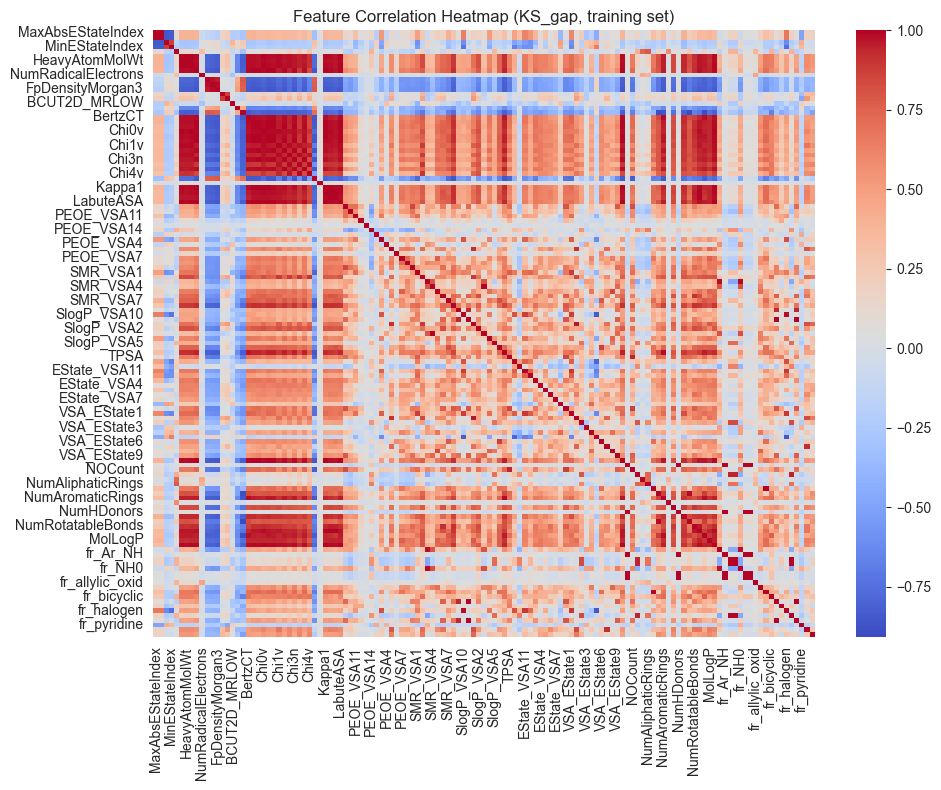

Highly correlated descriptors removed: 54
Remaining descriptors: 75
Optimal number of features: 75
Selected features: ['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'NumRadicalElectrons', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'HallKierAlpha', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA2', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NHOHCount', 'Nu

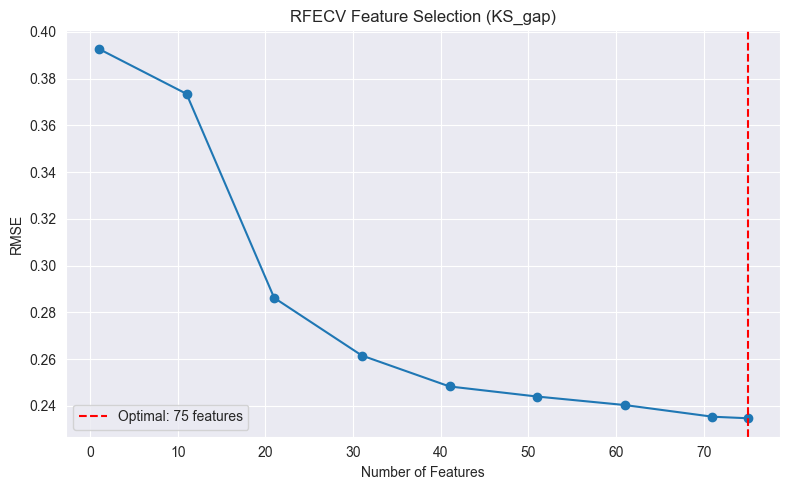


Best alpha: 0.001
Best CV RMSE: 0.233

Training R2:   0.695
Test R2:       0.683
Training RMSE: 0.227
Test RMSE:     0.232
Training MSE:  0.052
Test MSE:      0.054
Training MAE:  0.177
Test MAE:      0.179


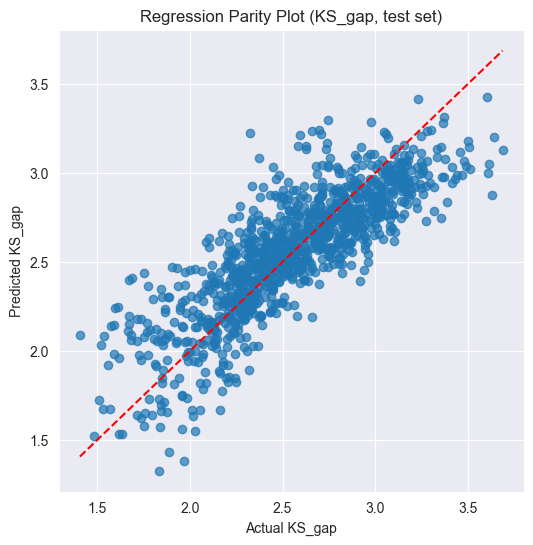

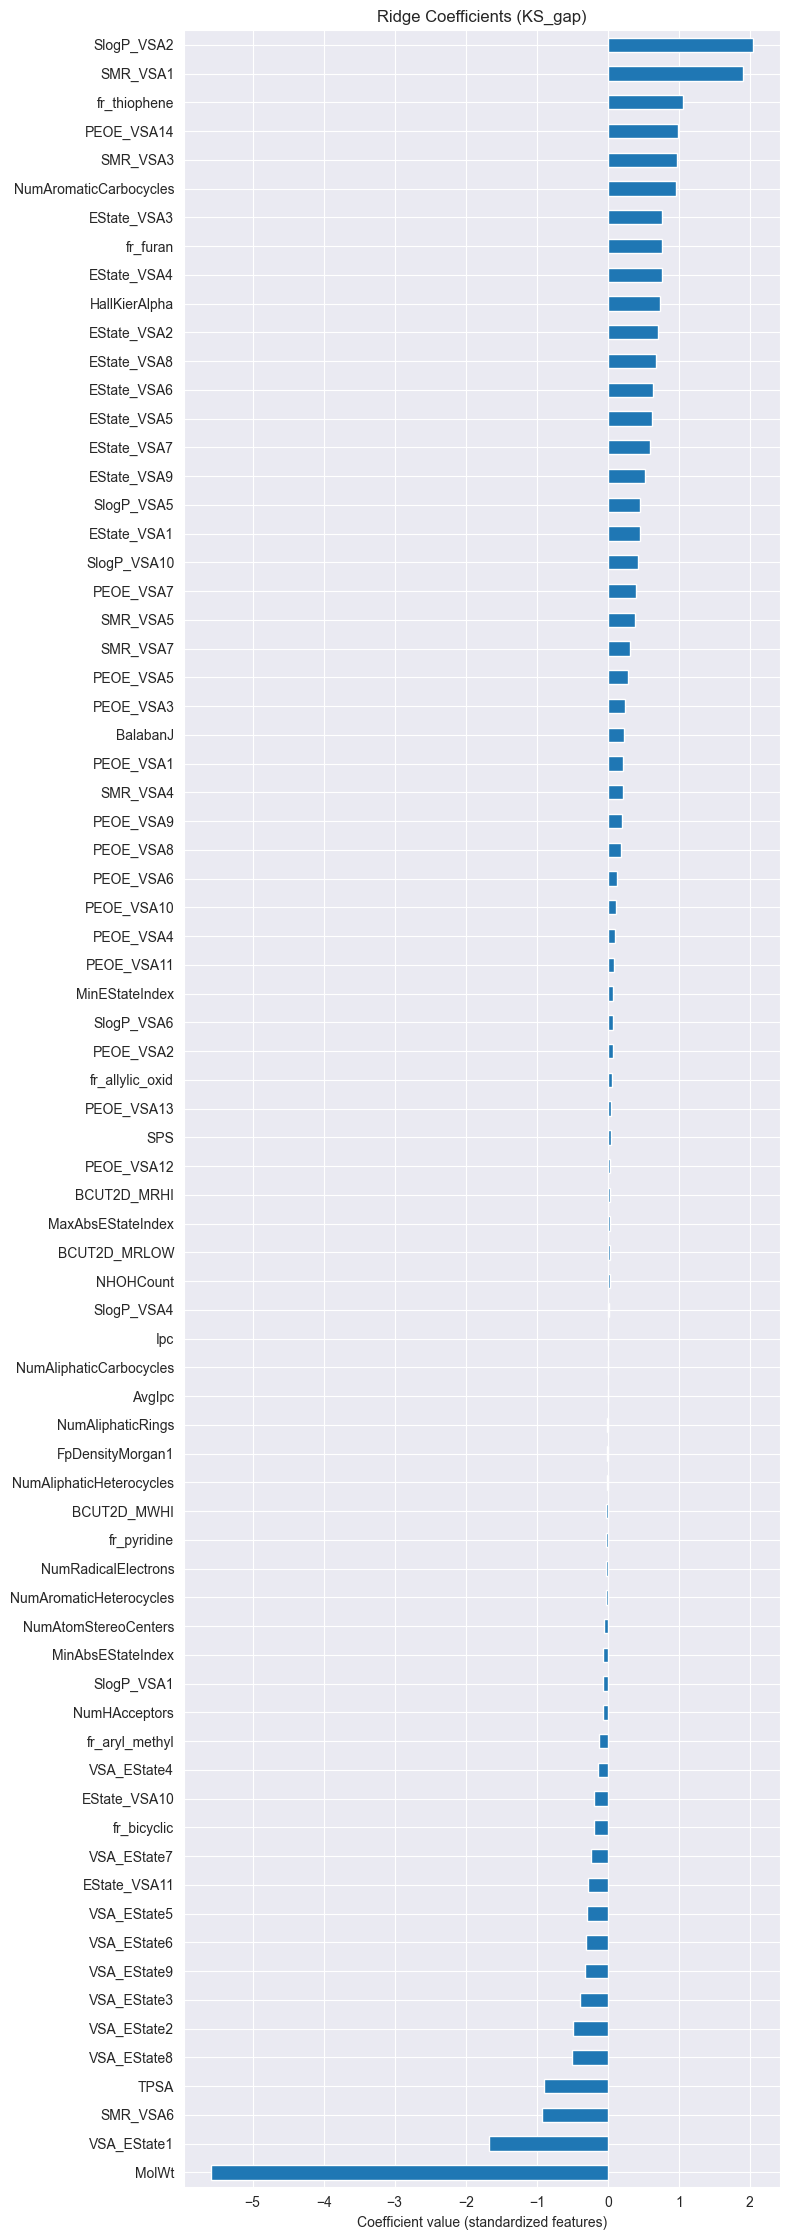


TARGET: E_opt
Rows available for this target: 3582
After removing near-constant descriptors: 128 left (started with 217)


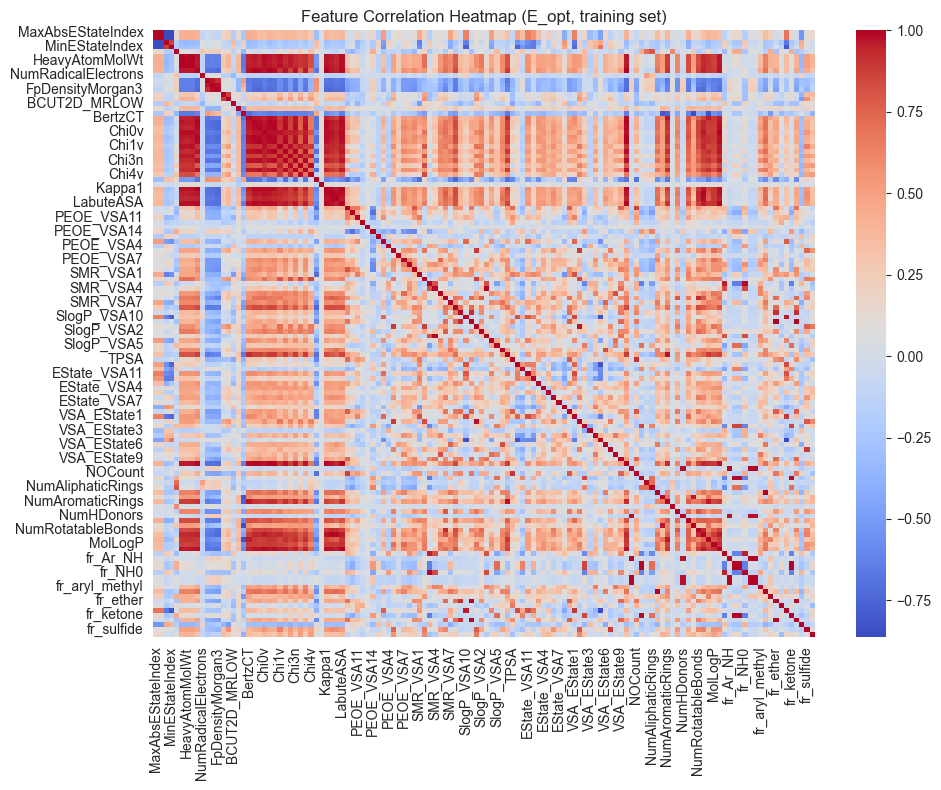

Highly correlated descriptors removed: 49
Remaining descriptors: 79
Optimal number of features: 79
Selected features: ['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'NumRadicalElectrons', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'HallKierAlpha', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_E

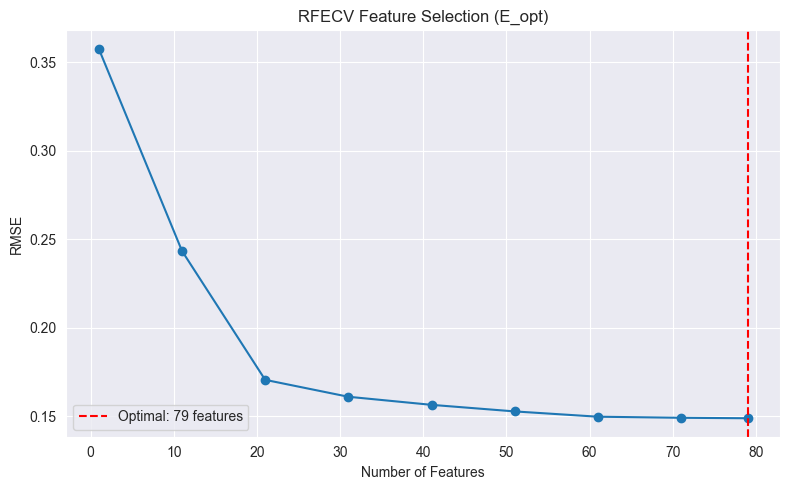


Best alpha: 1
Best CV RMSE: 0.149

Training R2:   0.865
Test R2:       0.844
Training RMSE: 0.141
Test RMSE:     0.151
Training MSE:  0.020
Test MSE:      0.023
Training MAE:  0.108
Test MAE:      0.115


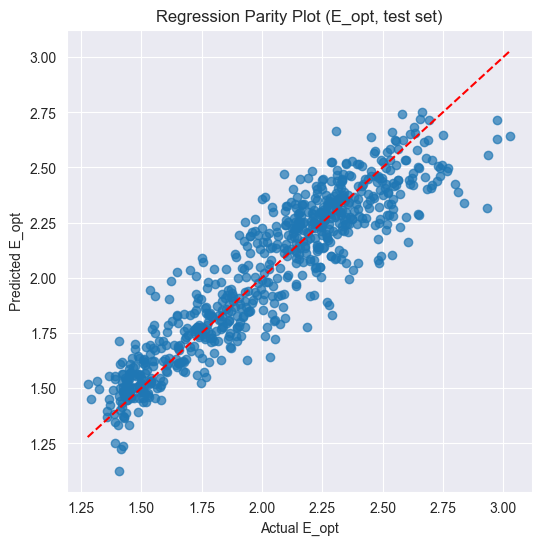

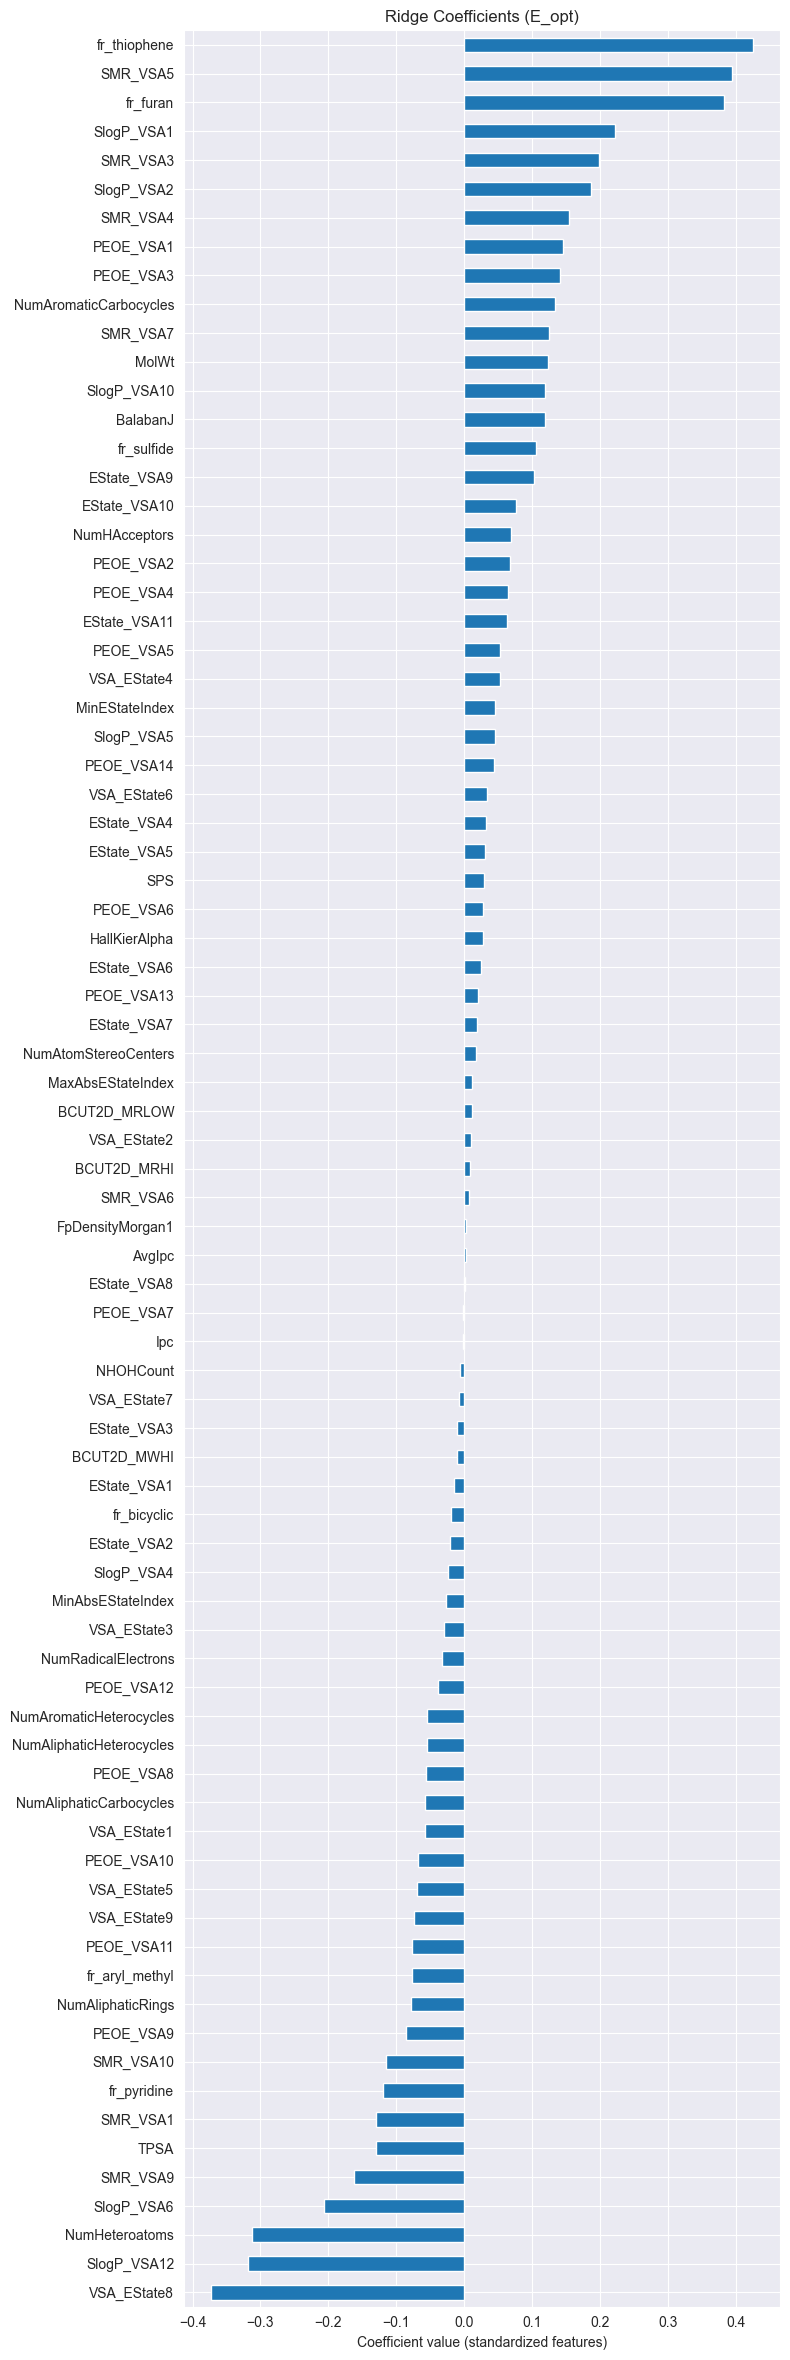

In [3]:
def run_pipeline(target_name, corr_threshold=0.9, cv_folds=5, rfecv_step=10):
    print(f"\n{'='*60}\nTARGET: {target_name}\n{'='*60}")

    #drop rows missing target
    df = data.dropna(subset=[target_name])
    X = df[desc_cols].replace([np.inf, -np.inf], np.nan)
    y = df[target_name]
    print(f"Rows available for this target: {len(df)}")

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    #imputing missing values with medians
    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    #remove near-constant descriptors
    var_selector = VarianceThreshold(threshold=0.01)
    X_train_var = pd.DataFrame(
        var_selector.fit_transform(X_train),
        columns=X_train.columns[var_selector.get_support()],
        index=X_train.index,
    )
    X_test_var = pd.DataFrame(
        var_selector.transform(X_test),
        columns=X_train_var.columns,
        index=X_test.index,
    )
    print(f"After removing near-constant descriptors: {X_train_var.shape[1]} left "
          f"(started with {X_train.shape[1]})")

    #correlation heatmap
    corr_matrix = X_train_var.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
    plt.title(f'Feature Correlation Heatmap ({target_name}, training set)')
    plt.tight_layout()
    plt.show()

    #dropping highly correlated features
    high_corr = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) >= corr_threshold:
                high_corr.add(corr_matrix.columns[i])
                break
    print(f'Highly correlated descriptors removed: {len(high_corr)}')
    X_train_reduced = X_train_var.drop(columns=high_corr)
    X_test_reduced = X_test_var.drop(columns=high_corr)
    print(f"Remaining descriptors: {X_train_reduced.shape[1]}")

    #scale
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_reduced),
        columns=X_train_reduced.columns, index=X_train_reduced.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_reduced),
        columns=X_test_reduced.columns, index=X_test_reduced.index,
    )

    #RFECV
    estimator = Ridge(alpha=1.0, random_state=42)
    rfecv = RFECV(estimator=estimator, step=rfecv_step, cv=KFold(cv_folds),
                  scoring='neg_mean_squared_error', n_jobs=-1)
    rfecv.fit(X_train_scaled, y_train)
    print("Optimal number of features:", rfecv.n_features_)
    selected = list(X_train_scaled.columns[rfecv.support_])
    print("Selected features:", selected)

    #RFECV plot
    rmse_scores = np.sqrt(-rfecv.cv_results_['mean_test_score'])
    n_total_features = X_train_scaled.shape[1]
    feature_counts = [1 + i * rfecv_step if 1 + i * rfecv_step < n_total_features else n_total_features
                       for i in range(len(rmse_scores))]

    plt.figure(figsize=(8, 5))
    plt.plot(feature_counts, rmse_scores, marker='o')
    plt.axvline(rfecv.n_features_, color='red', linestyle='--',
                label=f'Optimal: {rfecv.n_features_} features')
    plt.xlabel("Number of Features")
    plt.ylabel("RMSE")
    plt.title(f"RFECV Feature Selection ({target_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    X_train_final = X_train_scaled[selected]
    X_test_final = X_test_scaled[selected]

    #GridSearchCV
    ridge_param_grid = {
        "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    }

    grid_search = GridSearchCV(
        estimator=Ridge(random_state=42),
        param_grid=ridge_param_grid,
        cv=KFold(cv_folds),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    grid_search.fit(X_train_final, y_train)

    print(f"\nBest alpha: {grid_search.best_params_['alpha']}")
    print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.3f}")

    #Fit final model using the best alpha
    best_model = Ridge(**grid_search.best_params_, random_state=42)
    best_model.fit(X_train_final, y_train)

    train_pred = best_model.predict(X_train_final)
    test_pred = best_model.predict(X_test_final)

    print(f"\nTraining R2:   {r2_score(y_train, train_pred):.3f}")
    print(f"Test R2:       {r2_score(y_test, test_pred):.3f}")
    print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.3f}")
    print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, test_pred)):.3f}")
    print(f"Training MSE:  {mean_squared_error(y_train, train_pred):.3f}")
    print(f"Test MSE:      {mean_squared_error(y_test, test_pred):.3f}")
    print(f"Training MAE:  {mean_absolute_error(y_train, train_pred):.3f}")
    print(f"Test MAE:      {mean_absolute_error(y_test, test_pred):.3f}")

    #parity plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, test_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel(f'Actual {target_name}')
    plt.ylabel(f'Predicted {target_name}')
    plt.title(f'Regression Parity Plot ({target_name}, test set)')
    plt.show()

    #coefficient plot
    coefs = pd.Series(best_model.coef_, index=selected).sort_values()
    plt.figure(figsize=(8, max(4, 0.3 * len(coefs))))
    coefs.plot(kind='barh')
    plt.title(f'Ridge Coefficients ({target_name})')
    plt.xlabel('Coefficient value (standardized features)')
    plt.tight_layout()
    plt.show()

    return best_model, scaler, selected, grid_search.best_params_


models_by_target = {}
for target in target_vars:
    models_by_target[target] = run_pipeline(target)